In [ ]:
import sqlite3

In [ ]:
connect = sqlite3.connect('demo310526.db')

In [ ]:
!ls demo*

demo310526.db


In [ ]:
cur = connect.cursor()

In [ ]:
cur.execute("CREATE TABLE IF NOT EXISTS  users (id TEXT , password TEXT, age INT )")

In [ ]:
cur.execute("INSERT INTO users VALUES ('admin','test123$',25)")

In [ ]:
list(cur.execute("SELECT * FROM users"))

[('admin', 'test123$', 25)]

In [ ]:
cur.execute("INSERT INTO users VALUES ('user1','alpha123$',21)")

In [ ]:
list(cur.execute("SELECT * FROM users"))

[('admin', 'test123$', 25), ('user1', 'alpha123$', 21)]

In [ ]:
print(list(cur.execute("SELECT * FROM users")))

[('admin', 'test123$', 25), ('user1', 'alpha123$', 21)]


In [ ]:
cur.execute("UPDATE users SET password='beta123$' WHERE id='admin'")

In [ ]:
print(list(cur.execute("SELECT * FROM users")))

[('admin', 'beta123$', 25), ('user1', 'xyz123$', 21)]


In [ ]:
cur.execute("DELETE FROM users WHERE id='admin'")

In [ ]:
print(list(cur.execute("SELECT * FROM users")))

[('user1', 'xyz123$', 21)]


# Integrate python with sql using Flask

In [ ]:
from flask import Flask
import sqlite3

app = Flask(__name__)

@app.route('/test')
def test():
  connect = sqlite3.connect('demo3105261.db')
  cur = connect.cursor()
  cur.execute("CREATE TABLE IF NOT EXISTS  users (id TEXT , password TEXT, age INT )")
  cur.execute("INSERT INTO users VALUES ('admin','test123$',25)")
  data=list(cur.execute("SELECT * FROM users"))
  connect.commit()
  connect.close()
  return {"users_data": data}


app.run(port=5005)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5005
INFO:werkzeug:Press CTRL+C to quit


# Register (Insert) and Display users (Select)

In [ ]:
from flask import Flask,request
import sqlite3

app = Flask(__name__)

@app.route('/register',methods=['POST'])
def test():
    connect = sqlite3.connect('demo3105261.db')
    cur = connect.cursor()
    cur.execute("CREATE TABLE IF NOT EXISTS  users (id TEXT , password TEXT, age INT )")
    data = request.get_json()
    print("INSERT INTO users VALUES ('{0}' , '{1}' , {2})".format(data['id'],data['password'],data['age']))
    cur.execute("INSERT INTO users VALUES ('{0}' , '{1}' , {2})".format(data['id'],data['password'],data['age']))
    connect.commit()
    connect.close()
    return "User registered successfully"


@app.route('/show')
def show():
  connect = sqlite3.connect('demo3105261.db')
  cur = connect.cursor()
  records=list(cur.execute("SELECT * FROM users"))
  connect.close()
  return {"users_data": records}

app.run(port=5005)


# POSt data - {"id":"admin","password":"test123$","age":25}

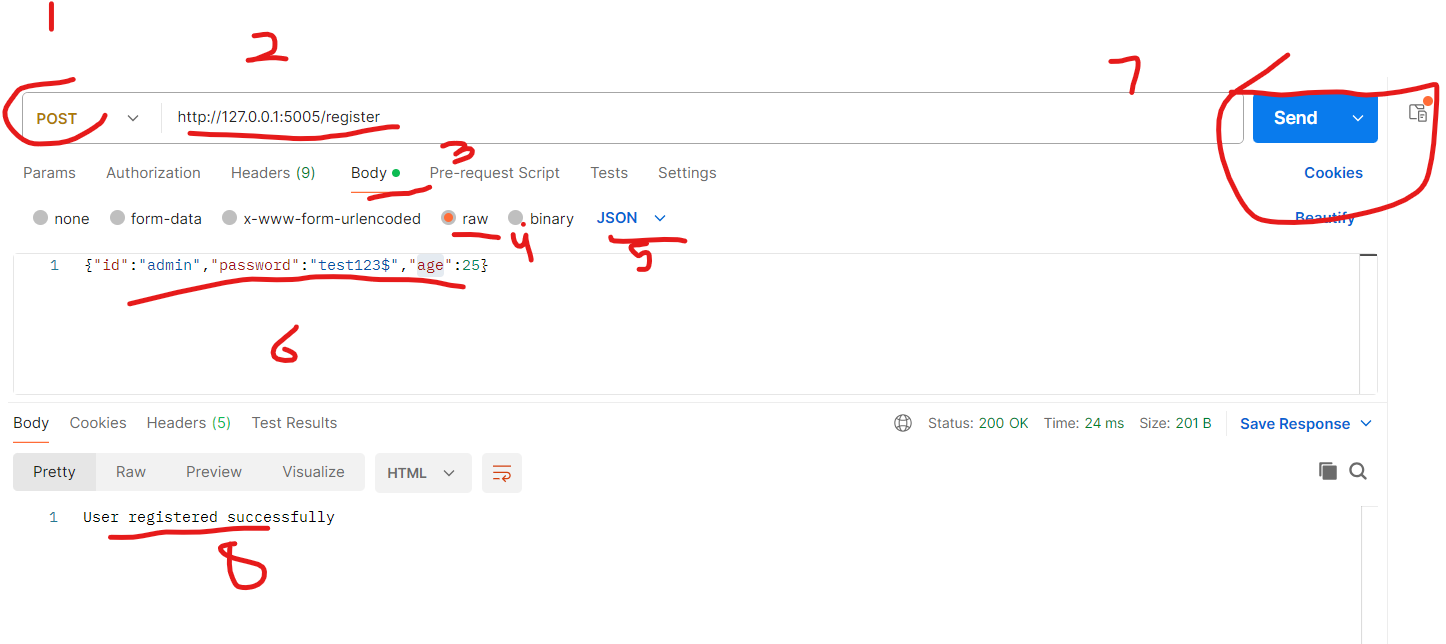

# SQL and Flask integration with CRUD operations

In [ ]:
from flask import Flask,request
import sqlite3

app = Flask(__name__)

@app.route('/register',methods=['POST'])
def test():
    connect = sqlite3.connect('demo3105261.db')
    cur = connect.cursor()
    cur.execute("CREATE TABLE IF NOT EXISTS  users (id TEXT , password TEXT, age INT )")
    data = request.get_json()
    print("INSERT INTO users VALUES ('{0}' , '{1}' , {2})".format(data['id'],data['password'],data['age']))
    cur.execute("INSERT INTO users VALUES ('{0}' , '{1}' , {2})".format(data['id'],data['password'],data['age']))
    connect.commit()
    connect.close()
    return "User registered successfully"


@app.route('/show')
def show():
  connect = sqlite3.connect('demo3105261.db')
  cur = connect.cursor()
  records=list(cur.execute("SELECT * FROM users"))
  connect.close()
  return {"users_data": records}


@app.route('/update',methods=['POST'])
def update():
    connect = sqlite3.connect('demo3105261.db')
    cur = connect.cursor()
    data = request.get_json()
    cur.execute("UPDATE users SET password='{1}' where id='{0}'".format(data['id'],data['password']))
    connect.commit()
    connect.close()
    return "User's password updated successfully"

@app.route('/remove',methods=['POST'])
def delete():
    connect = sqlite3.connect('demo3105261.db')
    cur = connect.cursor()
    data = request.get_json()
    cur.execute("DELETE FROM users where id='{0}'".format(data['id']))
    connect.commit()
    connect.close()
    return "User's account deleted successfully"

app.run(port=5005)